# Multi-start optimizer — results viewer

Loads the pickle written by `python-scripts/multistart_optimizer.py` and produces:
- logL distribution histogram
- 4-param corner scatter (coloured by Delta logL)
- Full 8D corner
- Mode cluster summary

**Run the optimizer in a terminal first:**
```bash
mkdir -p logs
nohup python python-scripts/multistart_optimizer.py > logs/multistart.log 2>&1 &
tail -f logs/multistart.log
```
The pickle is updated after every start, so you can load partial results while it is still running.

In [294]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

REPO = os.path.expanduser(
    '~/aispp-sims/gaussian-wavefront-spatially-resolved-inference')

# Change to match what the script wrote
RESULTS_FILE = os.path.join(
    REPO, 'results', 'multistart_shot0_bins32_ngh12.pkl')

with open(RESULTS_FILE, 'rb') as f:
    data = pickle.load(f)

results       = data['results']
theta_true_z0 = data['theta_true_z0']
ll_true       = data['ll_true']
PARAM_NAMES   = data['param_names']
cfg           = data['config']

PARAM_UNITS = ['um','um','um/s','um/s','um','um','um/s','um/s']
PARAM_SCALE = [1e-6] * 8

n_done = len(results)
thetas = np.array([r['theta_hat'] for r in results])
lls    = np.array([r['ll_hat']    for r in results])
ll_max = lls.max()
delta  = lls - ll_max
n_ok   = sum(r['success'] for r in results)

print(f'Loaded {n_done}/{cfg["n_starts"]} starts  '
      f'(shot={cfg["shot"]}, bins={cfg["bins"]}, n_gh={cfg["n_gh"]})')
print(f'Converged: {n_ok}/{n_done}')
print(f'logL at true params: {ll_true:.2f}')
print(f'Best logL found:     {ll_max:.2f}  (Delta from true = {ll_max - ll_true:+.2f})')

Loaded 2/100 starts  (shot=0, bins=32, n_gh=12)
Converged: 2/2
logL at true params: 12932649.54
Best logL found:     12931870.19  (Delta from true = -779.35)


In [295]:
FILTER_DELTA = 200000.0
keep     = delta > -FILTER_DELTA
thetas_f = thetas[keep]
lls_f    = lls[keep]
delta_f  = delta[keep]
print(f'Kept {keep.sum()}/{n_done} within {FILTER_DELTA} logL units of best')

order    = np.argsort(-lls_f)
thetas_s = thetas_f[order]
lls_s    = lls_f[order]
delta_s  = delta_f[order]

print('\nTop-10:')
for j in range(min(10, len(lls_s))):
    th = thetas_s[j]
    print(f'  [{j+1:2d}] logL={lls_s[j]:.2f}  (D={delta_s[j]:.2f})  '
          f'mu_x0={th[0]*1e6:.2f}um  mu_vx0={th[2]*1e6:.2f}um/s  sx={th[4]*1e6:.1f}um')

c_vals   = delta_f#np.clip(delta_f, -50, 0)
norm     = plt.Normalize(vmin=-10000, vmax=0)
cmap     = cm.coolwarm
sort_ord = np.argsort(c_vals)
sm       = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

Kept 2/2 within 200000.0 logL units of best

Top-10:
  [ 1] logL=12931870.19  (D=0.00)  mu_x0=1.20um  mu_vx0=3.52um/s  sx=108.9um
  [ 2] logL=12931223.92  (D=-646.27)  mu_x0=1.48um  mu_vx0=3.44um/s  sx=92.8um


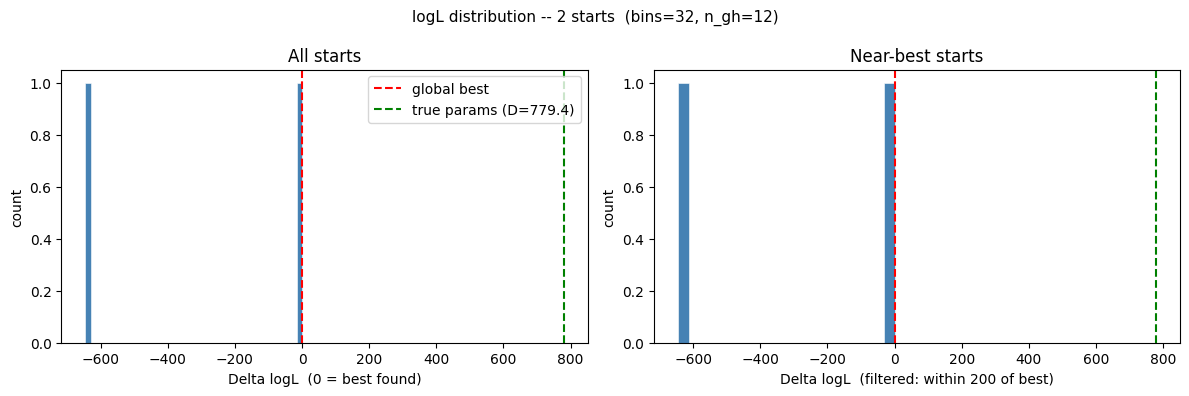

No significant gaps -> continuous basin or single dominant mode


In [296]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(delta, bins=40, color='steelblue', edgecolor='white', lw=0.4)
ax.axvline(0, color='r', ls='--', label='global best')
ax.axvline(ll_true - ll_max, color='g', ls='--',
           label=f'true params (D={ll_true-ll_max:.1f})')
ax.set_xlabel('Delta logL  (0 = best found)')
ax.set_ylabel('count')
ax.set_title('All starts')
ax.legend()

ax = axes[1]
ax.hist(delta_f, bins=20, color='steelblue', edgecolor='white', lw=0.4)
ax.axvline(0, color='r', ls='--')
ax.axvline(ll_true - ll_max, color='g', ls='--')
ax.set_xlabel('Delta logL  (filtered: within 200 of best)')
ax.set_ylabel('count')
ax.set_title('Near-best starts')

fig.suptitle(
    f'logL distribution -- {n_done} starts  (bins={cfg["bins"]}, n_gh={cfg["n_gh"]})',
    fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(REPO, 'results', 'multistart_logL_dist.pdf'),
            bbox_inches='tight')
plt.show()

gaps = -np.diff(np.sort(-lls_s))
big  = np.where(gaps > 2.0)[0]
if len(big):
    print(f'Gaps > 2 logL units at sorted-run indices: {big.tolist()}')
    print('  -> discrete mode structure detected')
else:
    print('No significant gaps -> continuous basin or single dominant mode')

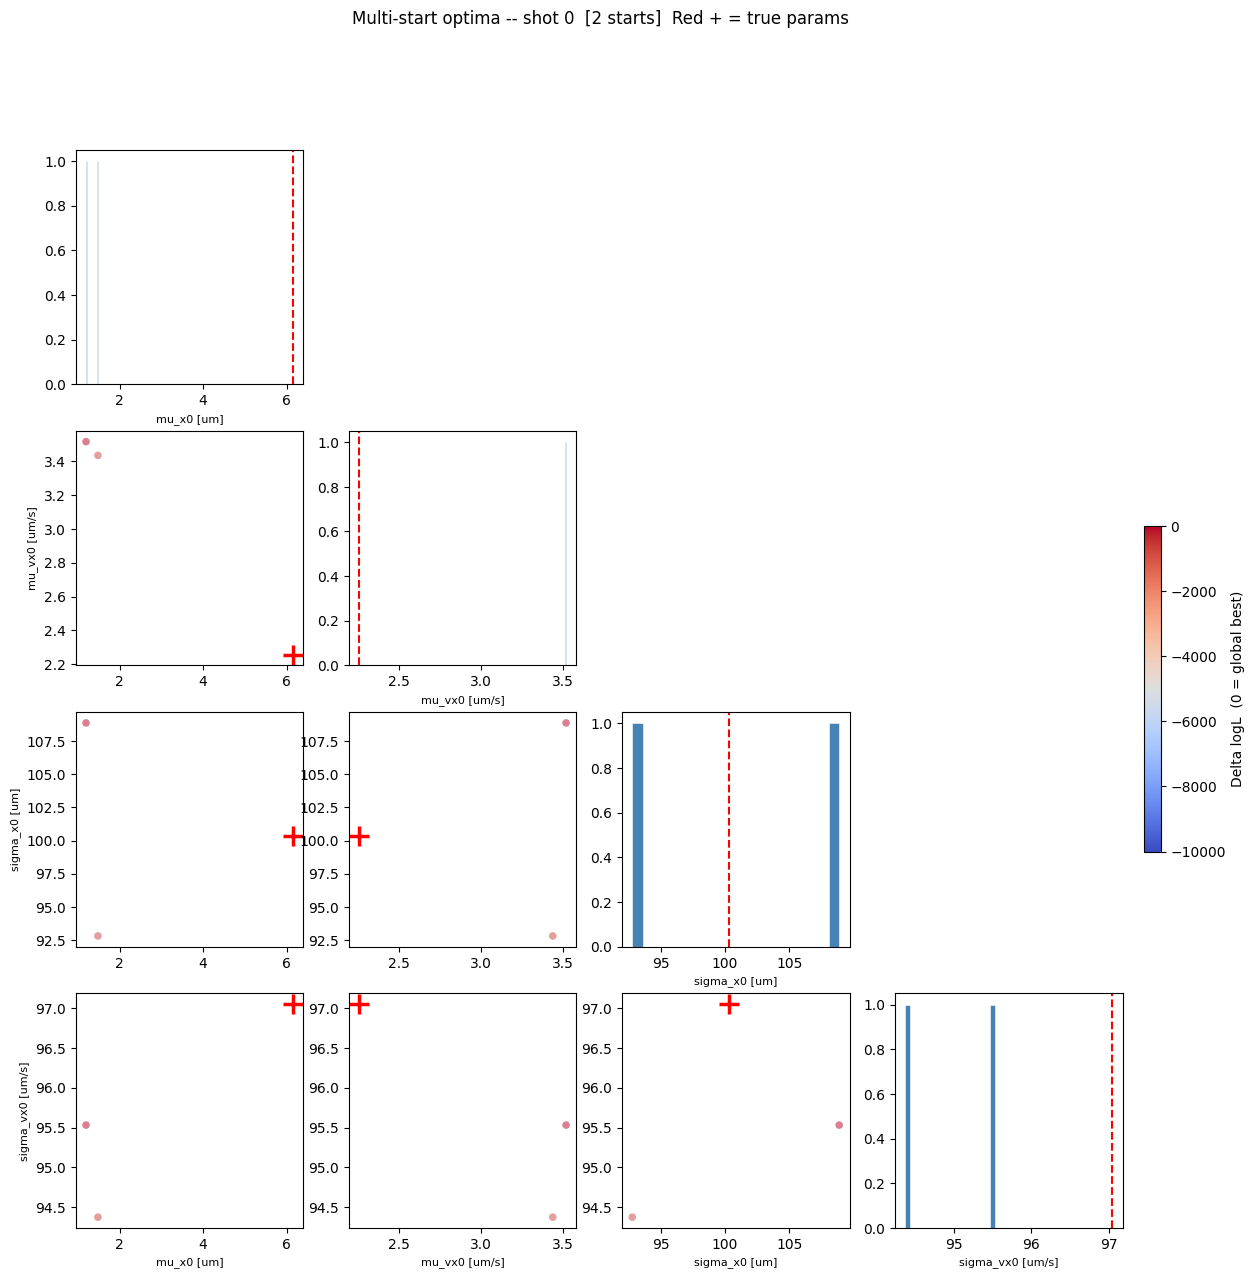

In [ ]:
# Corner scatter: mu_x0, mu_vx0, sigma_x0, sigma_vx0
SHOW_IDX = [0, 2, 4, 6]
n_show   = len(SHOW_IDX)

fig, axes = plt.subplots(n_show, n_show, figsize=(14, 14))

for ri in range(n_show):
    for ci in range(n_show):
        ax = axes[ri, ci]
        ix, iy = SHOW_IDX[ci], SHOW_IDX[ri]
        sx, sy = PARAM_SCALE[ix], PARAM_SCALE[iy]

        if ri == ci:
            ax.hist(thetas_f[sort_ord, ix] / sx, bins=20,
                    color='steelblue', edgecolor='white', lw=0.4)
            ax.axvline(theta_true_z0[ix] / sx, color='r', ls='--', lw=1.5)
            ax.set_xlabel(f'{PARAM_NAMES[ix]} [{PARAM_UNITS[ix]}]', fontsize=8)
        elif ri > ci:
            ax.scatter(
                thetas_f[sort_ord, ix] / sx,
                thetas_f[sort_ord, iy] / sy,
                c=c_vals[sort_ord], cmap=cmap, norm=norm,
                s=30, alpha=0.5, linewidths=0,)
            ax.plot(theta_true_z0[ix] / sx, theta_true_z0[iy] / sy,
                    'r+', ms=14, mew=2.5)
                        
            if ri == n_show - 1:
                ax.set_xlabel(f'{PARAM_NAMES[ix]} [{PARAM_UNITS[ix]}]', fontsize=8)
            if ci == 0:
                ax.set_ylabel(f'{PARAM_NAMES[iy]} [{PARAM_UNITS[iy]}]', fontsize=8)

        else:
            ax.axis('off')

cbar = fig.colorbar(sm, ax=axes, fraction=0.015, pad=0.02)
cbar.set_label('Delta logL  (0 = global best)', fontsize=10)
fig.suptitle(
    f'Multi-start optima -- shot {cfg["shot"]}  [{n_done} starts]  Red + = true params',
    fontsize=12)
plt.savefig(os.path.join(REPO, 'results', 'multistart_corner.pdf'),
            bbox_inches='tight')
plt.show()

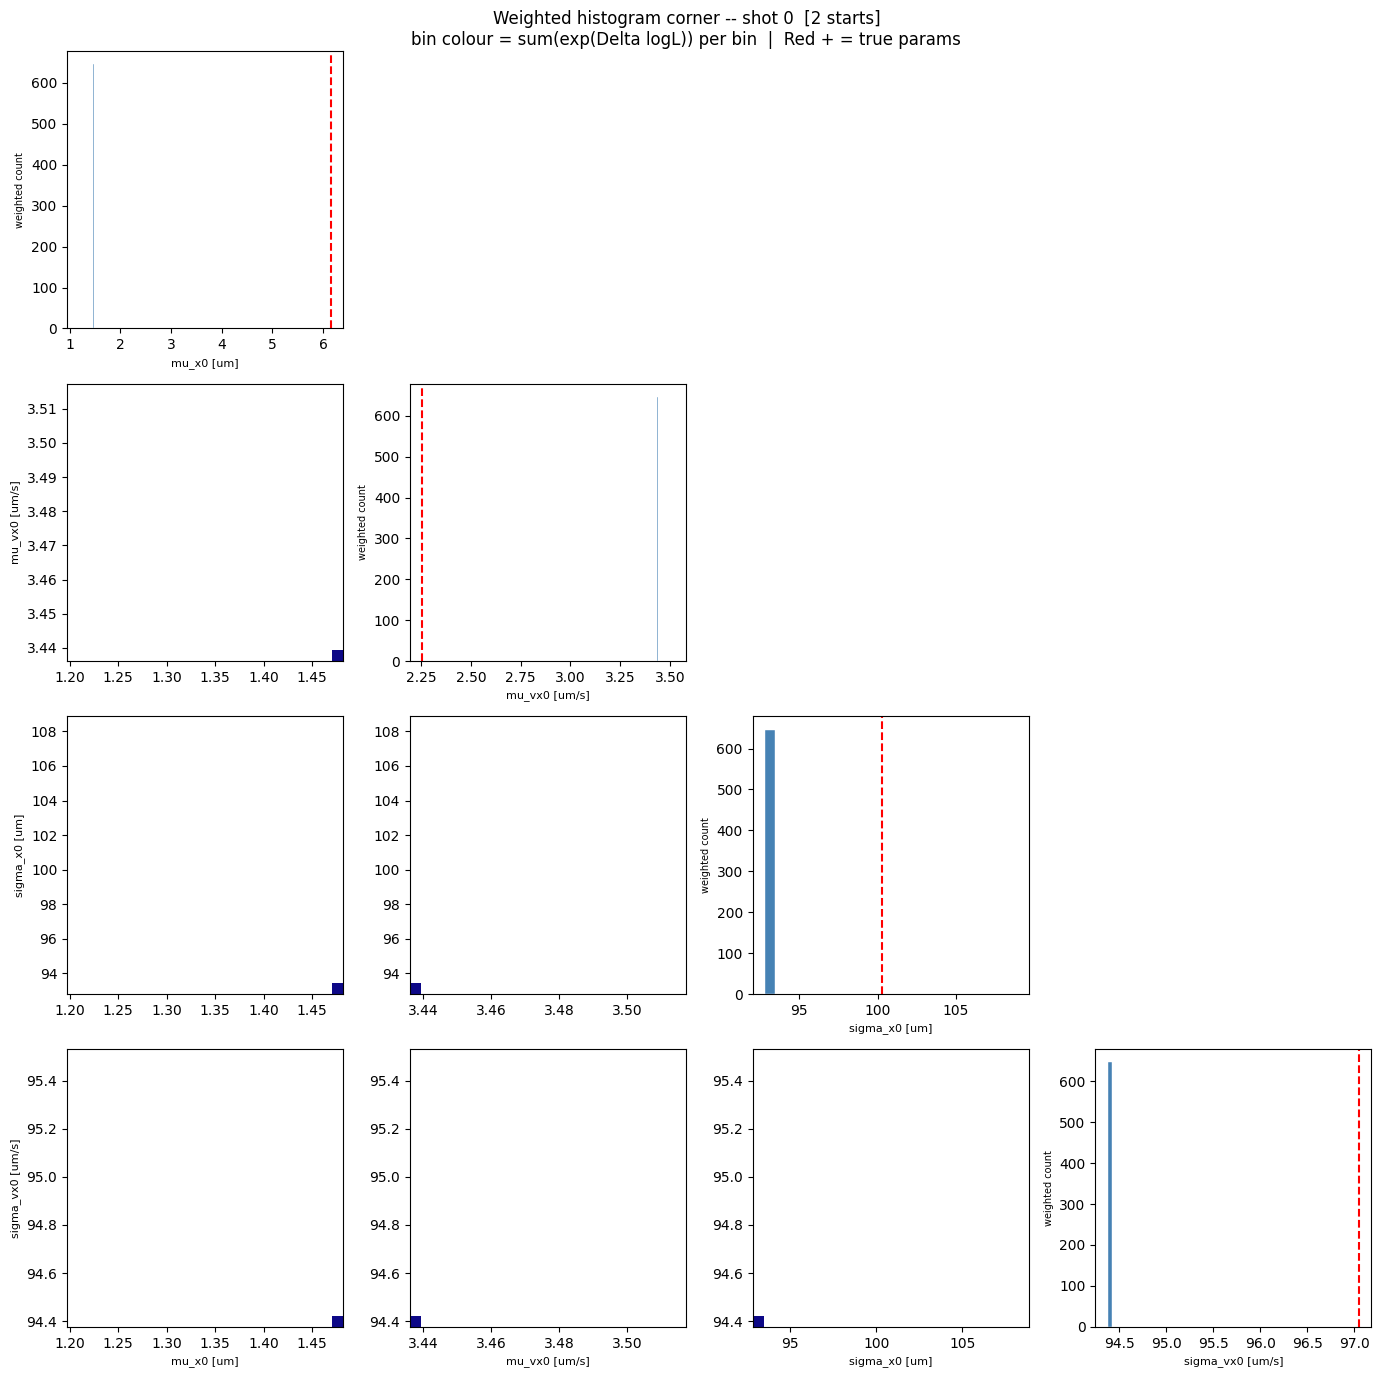

In [298]:
# Weighted histogram corner: mu_x0, mu_vx0, sigma_x0, sigma_vx0
# Weights = exp(delta_f) so high-logL optima dominate each bin.
SHOW_IDX = [0, 2, 4, 6]
n_show   = len(SHOW_IDX)
BINS_H   = 25

w = -delta_f#np.exp(delta_f)   # relative likelihood weight per start (max=1 at global best)

fig, axes = plt.subplots(n_show, n_show, figsize=(14, 14))

for ri in range(n_show):
    for ci in range(n_show):
        ax = axes[ri, ci]
        ix, iy = SHOW_IDX[ci], SHOW_IDX[ri]
        sx, sy = PARAM_SCALE[ix], PARAM_SCALE[iy]
        xvals = thetas_f[:, ix] / sx
        yvals = thetas_f[:, iy] / sy

        if ri == ci:
            ax.hist(xvals, bins=BINS_H, weights=w,
                    color='steelblue', edgecolor='white', lw=0.3)
            ax.axvline(theta_true_z0[ix] / sx, color='r', ls='--', lw=1.5)
            ax.set_xlabel(f'{PARAM_NAMES[ix]} [{PARAM_UNITS[ix]}]', fontsize=8)
            ax.set_ylabel('weighted count', fontsize=7)
        elif ri > ci:
            h, xe, ye, img = ax.hist2d(
                xvals, yvals, bins=BINS_H, weights=w,
                cmap='plasma', cmin=1e-30)
            ax.plot(theta_true_z0[ix] / sx, theta_true_z0[iy] / sy,
                    'r+', ms=14, mew=2.5)
            if ri == n_show - 1:
                ax.set_xlabel(f'{PARAM_NAMES[ix]} [{PARAM_UNITS[ix]}]', fontsize=8)
            if ci == 0:
                ax.set_ylabel(f'{PARAM_NAMES[iy]} [{PARAM_UNITS[iy]}]', fontsize=8)
        else:
            ax.axis('off')

fig.suptitle(
    f'Weighted histogram corner -- shot {cfg["shot"]}  [{n_done} starts]\n'
    f'bin colour = sum(exp(Delta logL)) per bin  |  Red + = true params',
    fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPO, 'results', 'multistart_corner_weighted.pdf'),
            bbox_inches='tight')
plt.show()

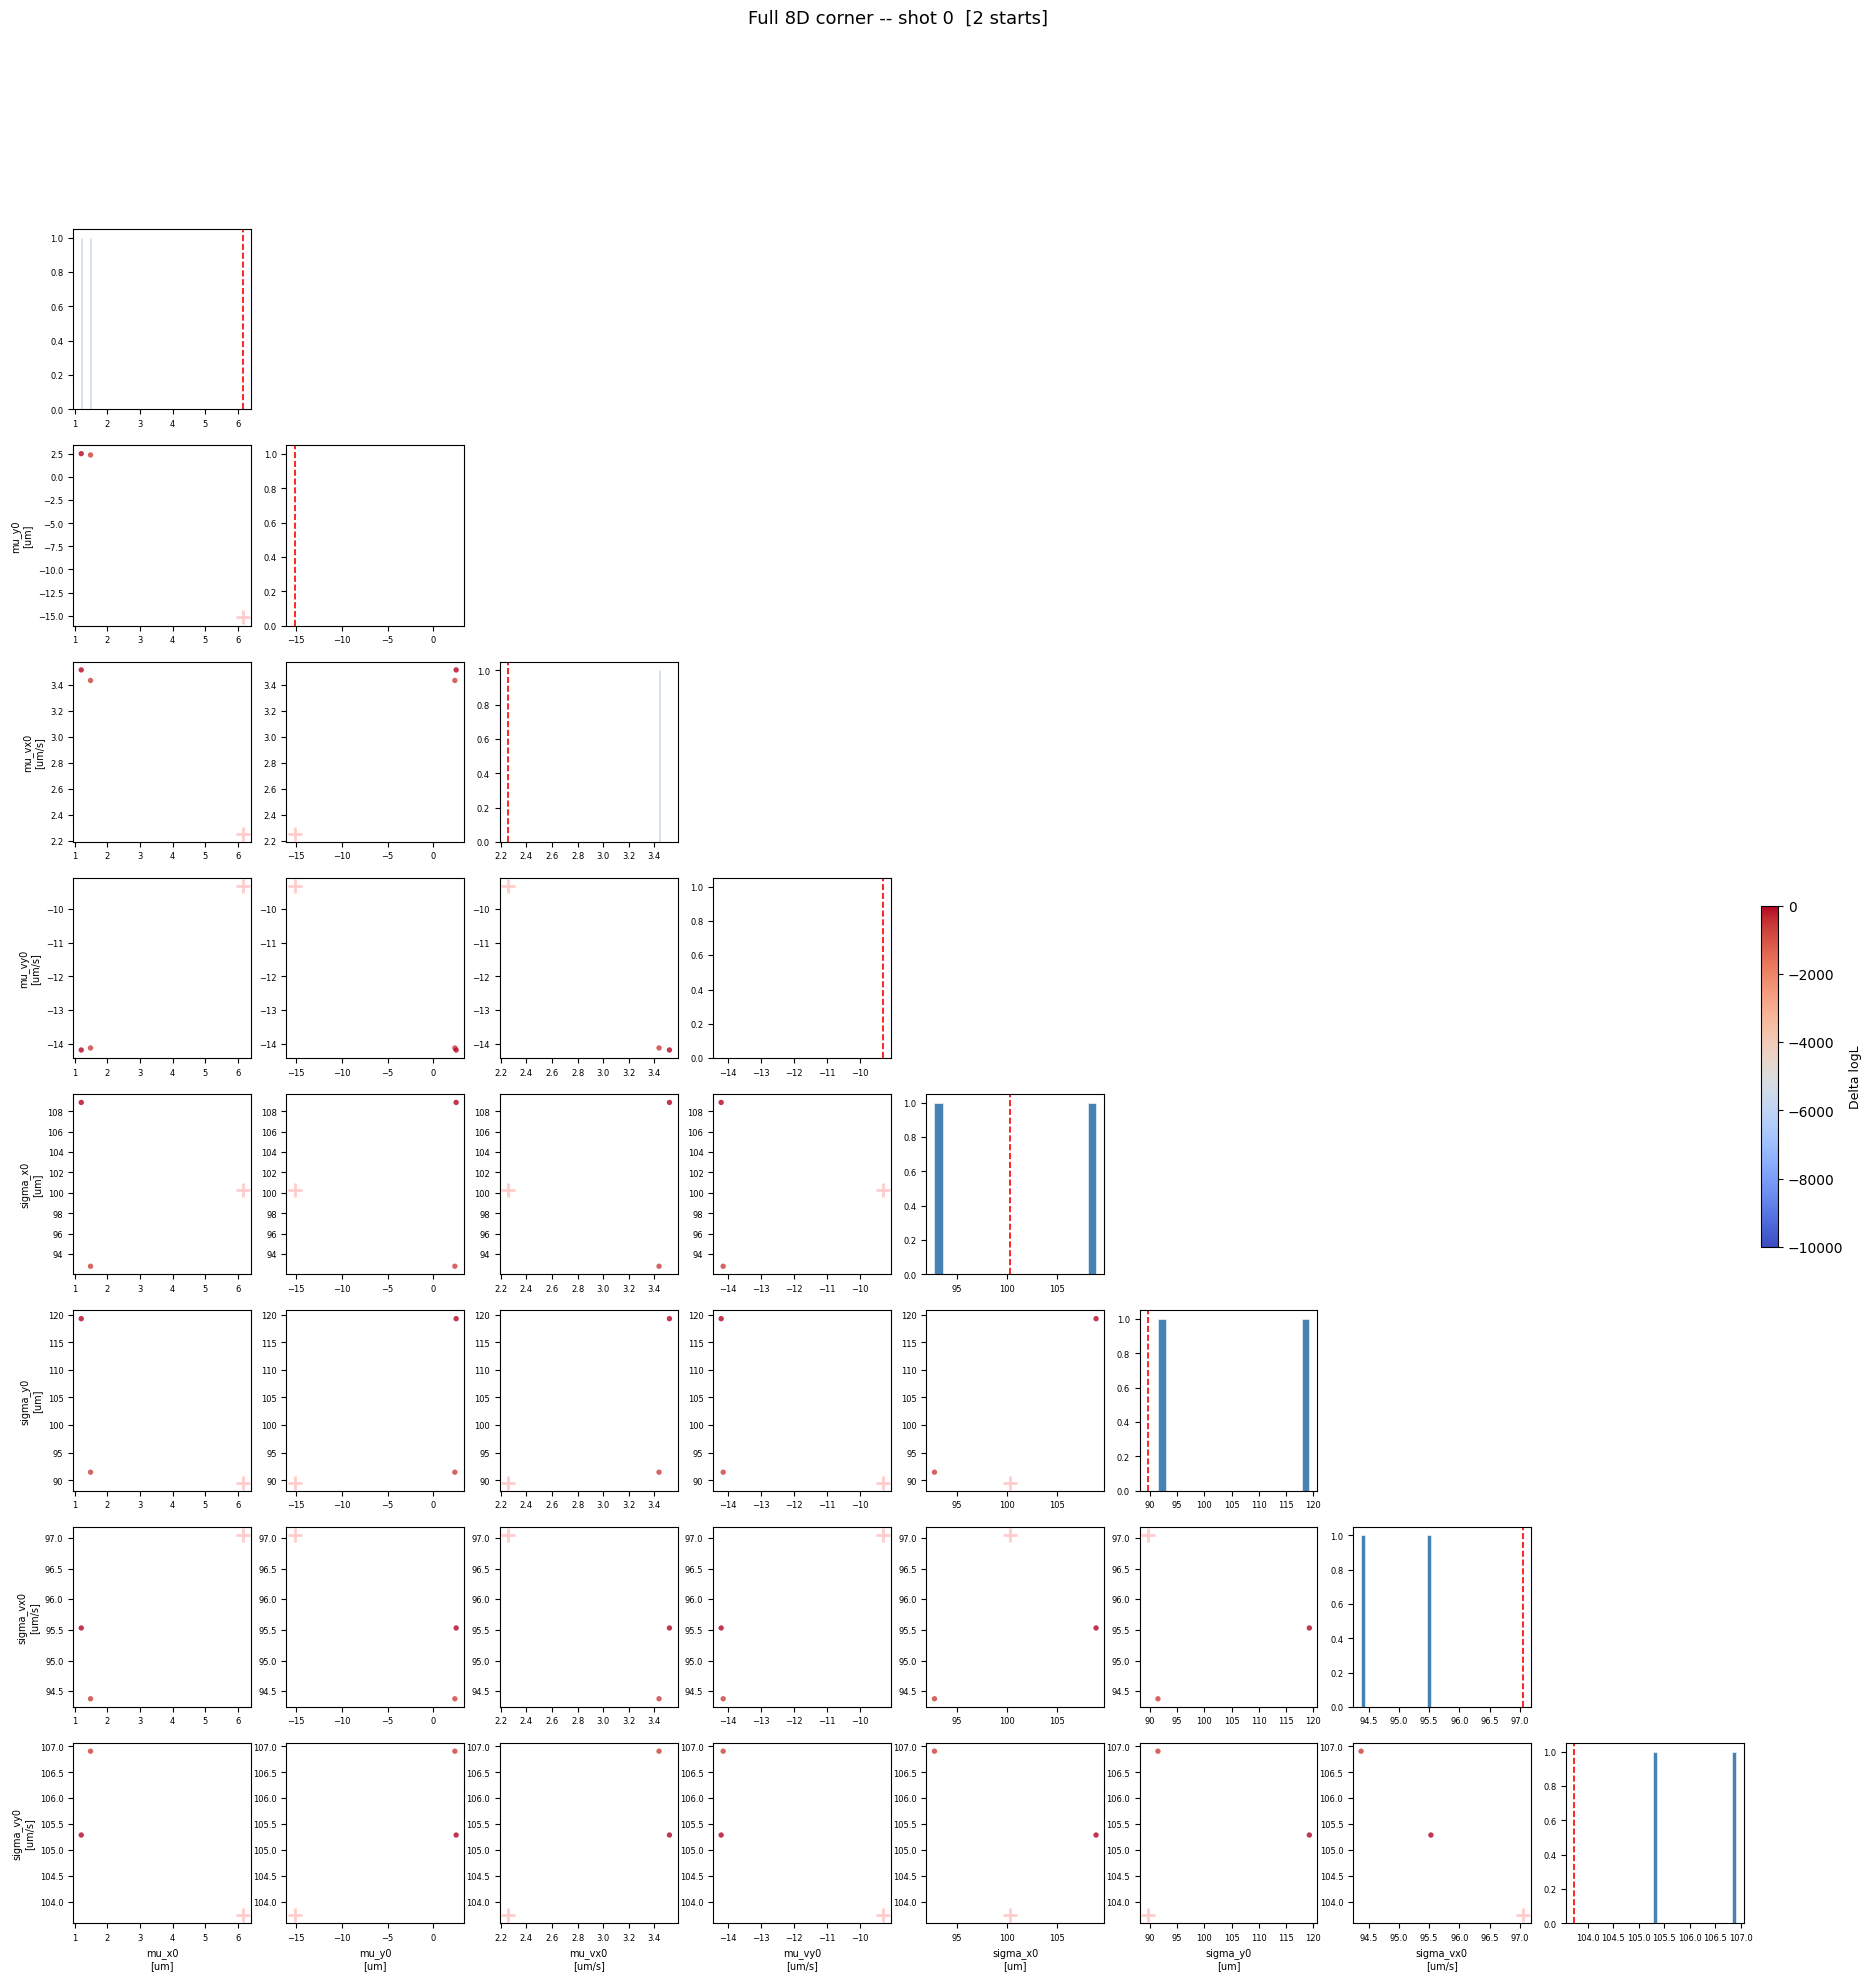

In [299]:
# Full 8D corner
fig, axes = plt.subplots(8, 8, figsize=(22, 22))

for ri in range(8):
    for ci in range(8):
        ax = axes[ri, ci]
        ix, iy = ci, ri
        sx, sy = PARAM_SCALE[ix], PARAM_SCALE[iy]

        if ri == ci:
            ax.hist(thetas_f[sort_ord, ix] / sx, bins=20,
                    color='steelblue', edgecolor='white', lw=0.4)
            ax.axvline(theta_true_z0[ix] / sx, color='r', ls='--', lw=1.2)
        elif ri > ci:
            ax.scatter(
                thetas_f[sort_ord, ix] / sx,
                thetas_f[sort_ord, iy] / sy,
                c=c_vals[sort_ord], cmap=cmap, norm=norm,
                s=15, alpha=0.8, linewidths=0)
            ax.plot(theta_true_z0[ix] / sx, theta_true_z0[iy] / sy,
                    'r+', ms=10, mew=2,alpha=0.2)
        else:
            ax.axis('off')

        if ri == 7 and ri != ci:
            ax.set_xlabel(f'{PARAM_NAMES[ci]}\n[{PARAM_UNITS[ci]}]', fontsize=7)
        if ci == 0 and ri != ci:
            ax.set_ylabel(f'{PARAM_NAMES[ri]}\n[{PARAM_UNITS[ri]}]', fontsize=7)
        ax.tick_params(labelsize=6)

fig.colorbar(sm, ax=axes, fraction=0.01, pad=0.01).set_label('Delta logL', fontsize=9)
fig.suptitle(f'Full 8D corner -- shot {cfg["shot"]}  [{n_done} starts]', fontsize=13)
plt.savefig(os.path.join(REPO, 'results', 'multistart_corner_8d.pdf'),
            bbox_inches='tight')
plt.show()

In [300]:
# Greedy mode clustering (5 um threshold per parameter)
CLUSTER_THR = np.full(8, 5e-6)

clusters = []
for th, ll in zip(thetas_f, lls_f):
    assigned = False
    for cl in clusters:
        if np.all(np.abs(th - cl['center']) < CLUSTER_THR):
            cl['members'] += 1
            cl['lls'].append(ll)
            if ll > cl['best_ll']:
                cl['best_ll'] = ll
                cl['center']  = th.copy()
            assigned = True
            break
    if not assigned:
        clusters.append({'center': th.copy(), 'best_ll': ll,
                          'members': 1, 'lls': [ll]})

clusters.sort(key=lambda c: -c['best_ll'])

print(f'Clusters (threshold {CLUSTER_THR[0]*1e6:.0f} um per param):')
for j, cl in enumerate(clusters):
    th = cl['center']
    print(f'  Mode {j+1}: logL={cl["best_ll"]:.2f}  '
          f'D={cl["best_ll"]-ll_max:.2f}  n={cl["members"]}  '
          f'mu_x0={th[0]*1e6:.2f}um  mu_vx0={th[2]*1e6:.2f}um/s  '
          f'sx={th[4]*1e6:.1f}um  svx={th[6]*1e6:.1f}um/s')

print(f'\nTrue: mu_x0={theta_true_z0[0]*1e6:.2f}um  '
      f'mu_vx0={theta_true_z0[2]*1e6:.2f}um/s  '
      f'sx={theta_true_z0[4]*1e6:.1f}um  svx={theta_true_z0[6]*1e6:.1f}um/s')
print(f'logL true: {ll_true:.2f}  (D from best = {ll_true-ll_max:.2f})')

if len(clusters) > 1:
    gap = clusters[0]['best_ll'] - clusters[1]['best_ll']
    print(f'\nlogL gap mode 1 -> mode 2: {gap:.2f}')
    if gap > 5:
        print('  -> Mode 1 dominates. MAP is reliable.')
    elif gap > 2:
        print('  -> Moderate gap. Marginalisation recommended.')
    else:
        print('  -> Near-degenerate modes. Must marginalise.')
else:
    print('\n-> Single mode. Posterior appears unimodal.')

Clusters (threshold 5 um per param):
  Mode 1: logL=12931870.19  D=0.00  n=1  mu_x0=1.20um  mu_vx0=3.52um/s  sx=108.9um  svx=95.5um/s
  Mode 2: logL=12931223.92  D=-646.27  n=1  mu_x0=1.48um  mu_vx0=3.44um/s  sx=92.8um  svx=94.4um/s

True: mu_x0=6.15um  mu_vx0=2.26um/s  sx=100.3um  svx=97.0um/s
logL true: 12932649.54  (D from best = 779.35)

logL gap mode 1 -> mode 2: 646.27
  -> Mode 1 dominates. MAP is reliable.


In [301]:
delta_f

array([   0.       , -646.2722491])